# Thesis data overview: acquisition + POC findings

This notebook summarizes where the project stands:

1. **Acquisition (part 1)** — 613 company-fiscal-year DFP filings pulled from CVM for the 66 non-financial Ibovespa constituents, 2015–2024.
2. **POC** — on 20 sector-diverse companies from that set, does isolating the debt note ("empréstimos, financiamentos e debêntures") and comparing it year-over-year with TF-IDF + cosine similarity produce a sane signal?

Full narrative writeup: [`reports/poc_note_extraction_findings.md`](../reports/poc_note_extraction_findings.md). Pipeline code: [`src/acquisition/`](../src/acquisition/), [`src/processing/`](../src/processing/).

**Status: two rounds.** Round 1 established the concept works but flagged note-*isolation* as the weak link. Round 2 fixed four concrete, generalizable extraction bugs found by chasing the round-1 outliers to ground in the actual PDFs — the reliable-cohort mean rose from 0.75 to 0.87 and every exact-zero degenerate score disappeared. This notebook reflects round 2.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

ROOT = Path("..")
DATA = ROOT / "data" / "interim"

# Fixed categorical order (never cycled/reassigned) + one-hue sequential ramp,
# per the project's dataviz conventions.
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = (
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948",
)
TEXT_PRIMARY, TEXT_SECONDARY, GRID = "#0b0b0b", "#52514e", "#e3e2dd"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": GRID,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "text.color": TEXT_PRIMARY,
    "axes.labelcolor": TEXT_SECONDARY,
    "xtick.color": TEXT_SECONDARY,
    "ytick.color": TEXT_SECONDARY,
    "font.size": 11,
})

DIAG_COLORS = {"font_heading": AQUA, "regex_only": YELLOW, "not_found": RED}
DIAG_LABELS = {"font_heading": "Precisely bounded", "regex_only": "Imprecise fallback", "not_found": "Not found"}

## 1. Acquisition (part 1): what's in the corpus

Non-financial Ibovespa constituents, 2015–2024 DFP filings, pulled from CVM's open-data portal + RAD system (see `src/acquisition/`).

In [2]:
universe = pd.read_csv(DATA / "ibov_non_financial_universe.csv")
log = pd.read_csv(DATA / "ibov_notes_download_log.csv")

n_companies = universe["CD_CVM"].nunique()
n_ok = (log["n_attachments_matched"] > 0).sum()
n_total = len(log)

print(f"{n_companies} non-financial Ibovespa companies")
print(f"{n_ok}/{n_total} company-fiscal-year filings acquired ({n_ok/n_total:.1%})")
print(f"Years covered: {log['ANO'].min()}–{log['ANO'].max()}")

66 non-financial Ibovespa companies
613/613 company-fiscal-year filings acquired (100.0%)
Years covered: 2015–2024


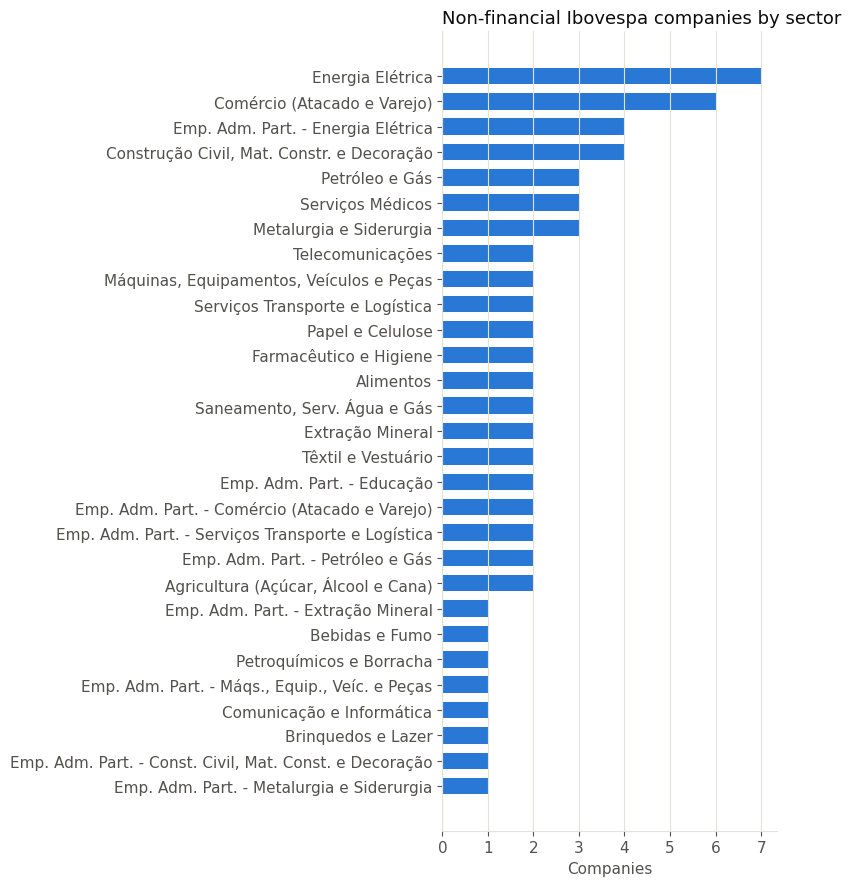

In [3]:
# Companies by sector -- one hue (categorical identity isn't the point here,
# magnitude is), horizontal so the Portuguese sector names stay readable.
sector_counts = (
    universe.drop_duplicates("CD_CVM")["SETOR_ATIV"]
    .value_counts()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 9))
ax.barh(sector_counts.index, sector_counts.values, color=BLUE, height=0.65)
ax.set_xlabel("Companies")
ax.set_title("Non-financial Ibovespa companies by sector", loc="left", fontsize=13, color=TEXT_PRIMARY)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

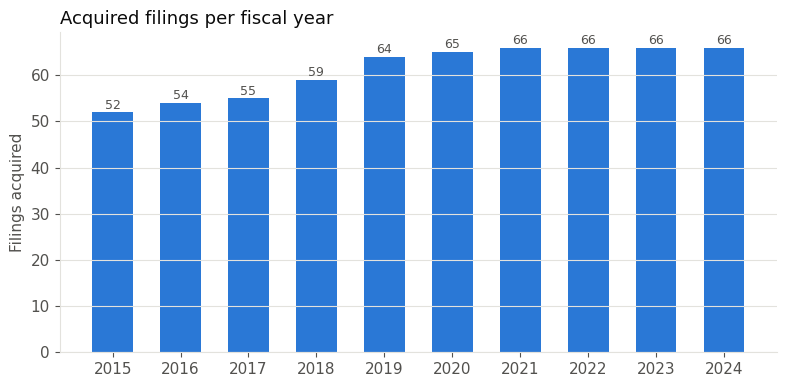

In [4]:
# Filings acquired per fiscal year -- magnitude over an ordered axis, single hue.
by_year = log[log["n_attachments_matched"] > 0].groupby("ANO").size()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(by_year.index.astype(str), by_year.values, color=BLUE, width=0.6)
ax.set_ylabel("Filings acquired")
ax.set_title("Acquired filings per fiscal year", loc="left", fontsize=13, color=TEXT_PRIMARY)
ax.grid(axis="x", visible=False)
for x, y in zip(by_year.index.astype(str), by_year.values):
    ax.text(x, y + 0.8, str(y), ha="center", fontsize=9, color=TEXT_SECONDARY)
fig.tight_layout()
plt.show()

## 2. POC: can the debt note be isolated automatically?

20 sector-diverse companies × up to 10 years = 200 company-years, checked against the note-locator in `src/processing/locate_note_section.py`. Three outcomes:

- **`font_heading`** — found a heading visually distinct from body text (bold + larger font). Reliable.
- **`regex_only`** — no visually distinct heading; fell back to "last keyword mention, capped at 500 lines." Imprecise.
- **`not_found`** — no debt-note mention matched at all.

In [5]:
POC = DATA / "poc"

sections = pd.DataFrame(
    json.loads(p.read_text(encoding="utf-8")) for p in sorted((POC / "sections").glob("*.json"))
)
sections["chars"] = sections["text"].str.len()

diag_counts = sections["diagnostic"].value_counts().reindex(["font_heading", "regex_only", "not_found"])
for diag, n in diag_counts.items():
    print(f"{DIAG_LABELS[diag]:22s} {n:3d}/{len(sections)}  ({n/len(sections):.0%})")

Precisely bounded       86/200  (43%)
Imprecise fallback      99/200  (50%)
Not found               15/200  (8%)


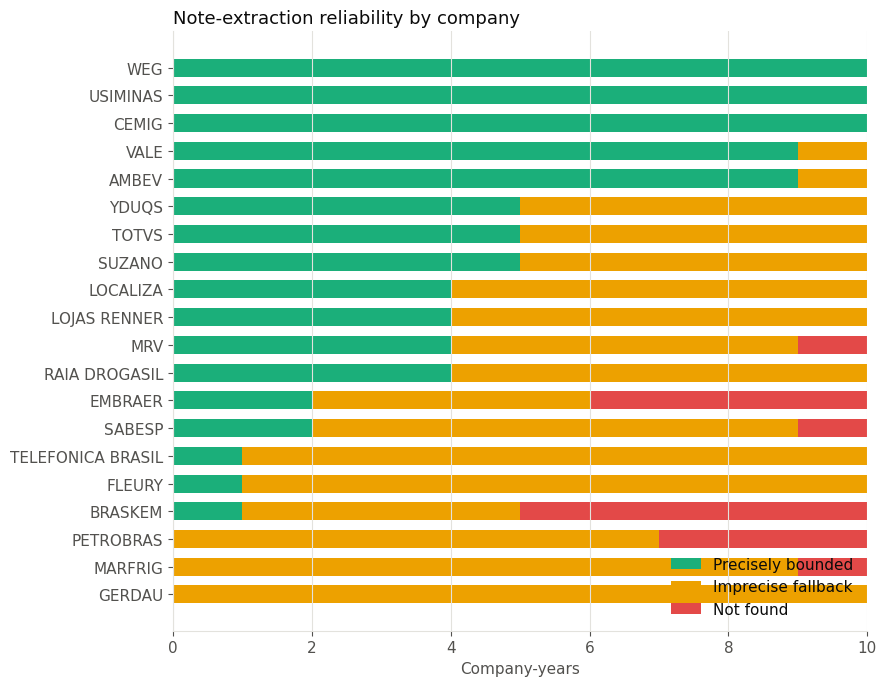

In [6]:
# Per-company reliability, ordered by how often extraction succeeded cleanly --
# status-style colors (green=reliable, amber=imprecise, red=missing), fixed order.
pivot = (
    sections.groupby(["name", "diagnostic"]).size().unstack(fill_value=0)
    .reindex(columns=["font_heading", "regex_only", "not_found"], fill_value=0)
)
pivot = pivot.loc[pivot["font_heading"].sort_values().index]

fig, ax = plt.subplots(figsize=(9, 7))
left = pd.Series(0, index=pivot.index)
for diag in ["font_heading", "regex_only", "not_found"]:
    ax.barh(pivot.index, pivot[diag], left=left, color=DIAG_COLORS[diag], label=DIAG_LABELS[diag], height=0.65)
    left = left + pivot[diag]

ax.set_xlabel("Company-years")
ax.set_title("Note-extraction reliability by company", loc="left", fontsize=13, color=TEXT_PRIMARY)
ax.legend(loc="lower right", frameon=False)
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

## 3. Does the similarity measure make sense?

Year-over-year TF-IDF cosine similarity, fit across the whole POC corpus so IDF reflects cross-sectional boilerplate (the same logic the literature relies on). Comparing **all pairs** to pairs where **both years got a reliable extraction** shows the distribution tightening up substantially once extraction noise is controlled for.

In [7]:
results = pd.read_csv(POC / "similarity_results.csv")
both_reliable = results[(results["diagnostic_prev"] == "font_heading") & (results["diagnostic_curr"] == "font_heading")]

print("All pairs:            n={:3d}  mean={:.2f}  median={:.2f}".format(
    len(results), results["cosine_similarity"].mean(), results["cosine_similarity"].median()))
print("Both years reliable:  n={:3d}  mean={:.2f}  median={:.2f}".format(
    len(both_reliable), both_reliable["cosine_similarity"].mean(), both_reliable["cosine_similarity"].median()))

All pairs:            n=165  mean=0.63  median=0.81
Both years reliable:  n= 64  mean=0.87  median=0.92


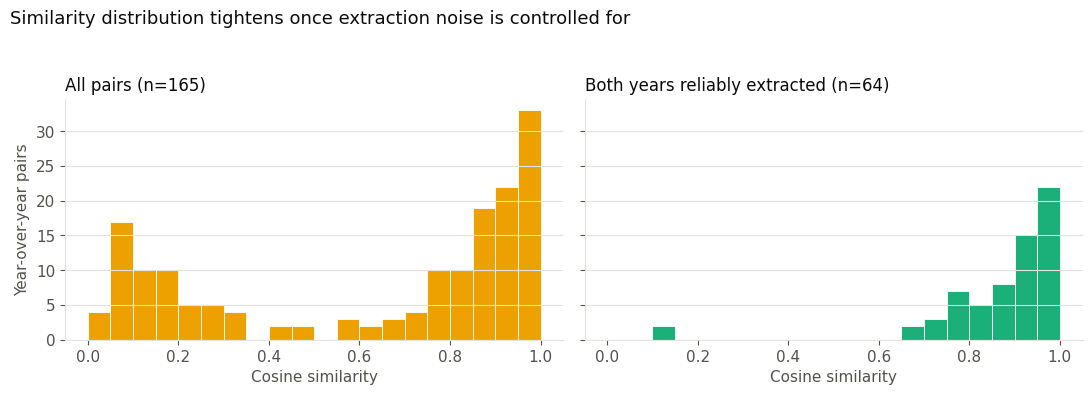

In [8]:
# Small multiples (same measure, two filters) rather than an overlaid
# histogram -- cleaner to compare than two semi-transparent fills.
bins = [i / 20 for i in range(21)]
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True, sharex=True)

axes[0].hist(results["cosine_similarity"], bins=bins, color=YELLOW, edgecolor="white", linewidth=0.6)
axes[0].set_title(f"All pairs (n={len(results)})", loc="left", fontsize=12, color=TEXT_PRIMARY)

axes[1].hist(both_reliable["cosine_similarity"], bins=bins, color=AQUA, edgecolor="white", linewidth=0.6)
axes[1].set_title(f"Both years reliably extracted (n={len(both_reliable)})", loc="left", fontsize=12, color=TEXT_PRIMARY)

for ax in axes:
    ax.set_xlabel("Cosine similarity")
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("Year-over-year pairs")
fig.suptitle("Similarity distribution tightens once extraction noise is controlled for", x=0.01, ha="left", fontsize=13, color=TEXT_PRIMARY)
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

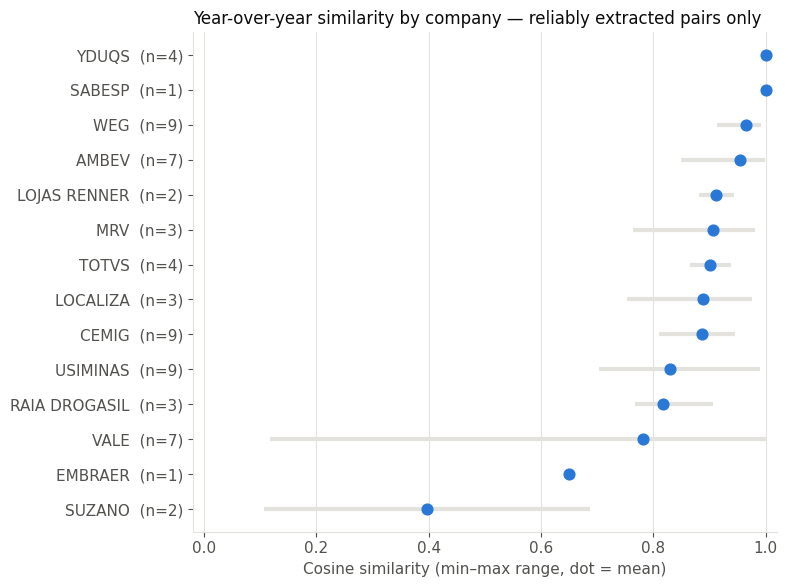

In [9]:
# Per-company mean similarity with min-max range, reliable pairs only.
# Sequential magnitude -> single hue; error bars show within-company spread.
by_company = (
    both_reliable.groupby("name")["cosine_similarity"]
    .agg(["mean", "min", "max", "count"])
    .sort_values("mean")
)

fig, ax = plt.subplots(figsize=(8, 6))
y = range(len(by_company))
ax.hlines(y, by_company["min"], by_company["max"], color=GRID, linewidth=3, zorder=1)
ax.scatter(by_company["mean"], y, color=BLUE, s=60, zorder=2, label="Mean")
ax.set_yticks(list(y))
ax.set_yticklabels([f"{n}  (n={c})" for n, c in zip(by_company.index, by_company["count"])])
ax.set_xlabel("Cosine similarity (min–max range, dot = mean)")
ax.set_title("Year-over-year similarity by company — reliably extracted pairs only", loc="left", fontsize=12, color=TEXT_PRIMARY)
ax.set_xlim(-0.02, 1.02)
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

## 4. Case studies: is the signal real?

Numbers alone can't answer this — reading the actual extracted text can. Two cases below: a genuine high-similarity pair (real content, real stability) and a degenerate one (extraction artifact, not a real "no change" finding).

In [10]:
import difflib


def show_pair(cd_cvm, year_prev, year_curr, n_diff_lines=16):
    d1 = json.loads((POC / "sections" / f"{cd_cvm}_{year_prev}.json").read_text(encoding="utf-8"))
    d2 = json.loads((POC / "sections" / f"{cd_cvm}_{year_curr}.json").read_text(encoding="utf-8"))
    row = results[(results["cd_cvm"] == int(cd_cvm)) & (results["year_prev"] == year_prev) & (results["year_curr"] == year_curr)].iloc[0]
    print(f"{d1['name']}: {year_prev} ({len(d1['text'])} chars) -> {year_curr} ({len(d2['text'])} chars)")
    print(f"cosine similarity = {row['cosine_similarity']:.4f}\n")
    diff = list(difflib.unified_diff(d1["text"].splitlines(), d2["text"].splitlines(), lineterm="", n=0))
    for line in diff[2 : 2 + n_diff_lines]:
        print(line)


print("### Genuine high similarity: WEG 2015 -> 2016 ###\n")
show_pair("005410", 2015, 2016)

### Genuine high similarity: WEG 2015 -> 2016 ###

WEG: 2015 (2516 chars) -> 2016 (2501 chars)
cosine similarity = 0.9918

@@ -1 +1 @@
-14 Financiamentos e empréstimos
+14 Empréstimos e Financiamentos
@@ -5 +5 @@
-líquida/ EBITDA, inclusas nos contratos com o BNDES, estão sendo atendidas.
+líquida/EBITDA, inclusas nos contratos com o BNDES, estão sendo atendidas.
@@ -7,2 +7,2 @@
-Encargos Anuais em 31/12/15
-NO BRASIL
+Encargos Anuais em 31/12/16
+EM MOEDA NACIONAL
@@ -10,2 +10,2 @@
-736.784
-1.086.642
+642.413
+637.552


In [11]:
print("### Extraction artifact, not a real finding: Yduqs (identical 648-char text, 4 different year-pairs) ###\n")
d = json.loads((POC / "sections" / "021016_2015.json").read_text(encoding="utf-8"))
print(f"Heading found: {d['heading']!r}\n")
print(d["text"])
print("\n^ This is a generic IFRS accounting-POLICY paragraph, not the actual note (Yduqs numbers the real")
print("  note separately, as 'Nota 11', found only in later years). Same text recurs across 2015-2019,")
print("  producing cosine similarity = 1.0000 -- a false 'no change' signal, not a real finding.")

### Extraction artifact, not a real finding: Yduqs (identical 648-char text, 4 different year-pairs) ###

Heading found: 'Empréstimos e financiamentos'

Empréstimos e financiamentos
Os empréstimos são reconhecidos, inicialmente, pelo valor justo, líquido dos custos incorridos
na transação e são, subsequentemente, demonstrados pelo custo amortizado. Qualquer
diferença entre os valores captados (líquidos dos custos da transação) e o valor total a pagar é
reconhecida na demonstração do resultado durante o período em que os empréstimos estejam
em aberto, utilizando o método da taxa efetiva de juros.
Os empréstimos são classificados como passivo circulante, a menos que o Grupo tenha um
direito incondicional de diferir a liquidação do passivo por, pelo menos, 12 meses após a data do
balanço.
2.15

^ This is a generic IFRS accounting-POLICY paragraph, not the actual note (Yduqs numbers the real
  note separately, as 'Nota 11', found only in later years). Same text recurs across 2015-2019,
  p

## Conclusion

**Go — and round 2 already improved the extraction step.** The similarity measure itself is sound and interpretable; round 1 traced every degenerate score to a specific, explainable extraction miss, not a flaw in the TF-IDF approach. Round 2 fixed four of those misses generally (see the report §5): a size-vs-purity tie-break bug, lettered-subsection markers colliding with Portuguese articles, table-of-contents entries mimicking real headings, and wrapped compound titles being cut short. Result: the reliable (`font_heading`) cohort's mean similarity rose from 0.75 to **0.87** with no more exact-zero artifacts, and Vale — the worst-behaved company in round 1 — is now stable across every year checked.

Still open (detailed in [`reports/poc_note_extraction_findings.md`](../reports/poc_note_extraction_findings.md) §5):
1. ~57% of company-years still don't get the precise `font_heading` extraction — Yduqs/Sabesp-style cases where the real note simply isn't styled distinctly need a different strategy (DFP index page, or an LLM fallback), not another heuristic tweak.
2. Add an automated red-flag check (exact 0/1 similarity, or notes under ~200 characters) so future runs surface likely extraction failures instead of silently feeding them into the analysis.